# 11 — Results Analysis & Comparison
**Project:** Quantum Machine Learning for Physiological Stress Classification  
**Author:** Kenza Qribis

---

## Purpose
Consolidate all experimental results into a unified comparison framework.
This notebook produces the final tables, plots, and analyses needed for the paper.

## Contents
1. Master results table — all models, all tasks
2. Training time comparison
3. WESAD binary: full model comparison plot
4. WESAD 3-class: full model comparison + stress/amusement overlap analysis
5. DREAMER binary: full model comparison
6. Cross-dataset generalization summary
7. Kernel concentration analysis (QSVM)
8. Quantum vs classical gap analysis
9. Per-subject variability analysis
10. Summary for paper

---


## 0. Configuration & Load All Results

In [12]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime

warnings.filterwarnings('ignore')

RESULTS_ROOT    = os.path.join('..', 'results')
PLOTS_DIR       = os.path.join(RESULTS_ROOT, 'plots', '11_results_analysis')
LOGS_DIR        = os.path.join(RESULTS_ROOT, 'logs')
OUTPUT_DATA_DIR = os.path.join(RESULTS_ROOT, 'output_data')
for d in [PLOTS_DIR, LOGS_DIR, OUTPUT_DATA_DIR]:
    os.makedirs(d, exist_ok=True)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

# ── Load all per-fold results ──────────────────────────────────────────────────
def load_if_exists(path):
    return pd.read_csv(path) if os.path.exists(path) else None

df_classical  = load_if_exists(os.path.join(OUTPUT_DATA_DIR,
                    'classical_baselines_per_fold.csv'))
df_cnn        = load_if_exists(os.path.join(OUTPUT_DATA_DIR,
                    'cnn_baseline_per_fold.csv'))
df_qsvm       = load_if_exists(os.path.join(OUTPUT_DATA_DIR,
                    'qsvm_all_results.csv'))
df_vqc        = load_if_exists(os.path.join(OUTPUT_DATA_DIR,
                    'vqc_all_results.csv'))
df_hybrid     = load_if_exists(os.path.join(OUTPUT_DATA_DIR,
                    'hybrid_cnn_qnn_per_fold.csv'))
df_cross      = load_if_exists(os.path.join(OUTPUT_DATA_DIR,
                    'cross_dataset_results.csv'))
df_overlap    = load_if_exists(os.path.join(OUTPUT_DATA_DIR,
                    'overlap_all_models.csv'))

print('=== Results loaded ===')
for name, df in [('Classical',df_classical),('CNN',df_cnn),
                  ('QSVM',df_qsvm),('VQC',df_vqc),
                  ('Hybrid',df_hybrid),('Cross',df_cross),
                  ('Overlap',df_overlap)]:
    status = f'{len(df)} rows' if df is not None else 'NOT FOUND'
    print(f'  {name:12s}: {status}')


=== Results loaded ===
  Classical   : 159 rows
  CNN         : 30 rows
  QSVM        : 2544 rows
  VQC         : 424 rows
  Hybrid      : 53 rows
  Cross       : 10 rows
  Overlap     : 5 rows


## 1. Master Results Table

In [13]:
rows = []

# ── Classical models ──────────────────────────────────────────────────────────
if df_classical is not None:
    for (task, model), g in df_classical.groupby(['task','model']):
        rows.append({
            'category'     : 'Classical',
            'model'        : model,
            'task'         : task,
            'f1_mean'      : g['f1'].mean(),
            'f1_std'       : g['f1'].std(),
            'accuracy_mean': g['accuracy'].mean(),
            'train_time_s' : g['train_time'].mean(),
        })

# ── CNN ───────────────────────────────────────────────────────────────────────
if df_cnn is not None:
    for task, g in df_cnn.groupby('task'):
        rows.append({
            'category'     : 'Deep Learning',
            'model'        : '1D-CNN',
            'task'         : task,
            'f1_mean'      : g['f1'].mean(),
            'f1_std'       : g['f1'].std(),
            'accuracy_mean': g['accuracy'].mean(),
            'train_time_s' : g['train_time'].mean(),
        })

# ── QSVM best per task ────────────────────────────────────────────────────────
if df_qsvm is not None:
    for task, g in df_qsvm.groupby('task'):
        best_cfg = g.groupby('config')['f1'].mean().idxmax()
        best     = g[g['config']==best_cfg]
        rows.append({
            'category'     : 'Quantum',
            'model'        : f'QSVM (best: {best_cfg})',
            'task'         : task,
            'f1_mean'      : best['f1'].mean(),
            'f1_std'       : best['f1'].std(),
            'accuracy_mean': best['accuracy'].mean(),
            'train_time_s' : best['train_time'].mean(),
        })

# ── VQC best per task ─────────────────────────────────────────────────────────
if df_vqc is not None:
    for task, g in df_vqc.groupby('task'):
        best_cfg = g.groupby('config')['f1'].mean().idxmax()
        best     = g[g['config']==best_cfg]
        rows.append({
            'category'     : 'Quantum',
            'model'        : f'VQC (best: {best_cfg})',
            'task'         : task,
            'f1_mean'      : best['f1'].mean(),
            'f1_std'       : best['f1'].std(),
            'accuracy_mean': best['accuracy'].mean(),
            'train_time_s' : best['train_time'].mean(),
        })

# ── Hybrid CNN-QNN ────────────────────────────────────────────────────────────
if df_hybrid is not None:
    for task, g in df_hybrid.groupby('task'):
        rows.append({
            'category'     : 'Hybrid Quantum',
            'model'        : 'Hybrid CNN-QNN',
            'task'         : task,
            'f1_mean'      : g['f1'].mean(),
            'f1_std'       : g['f1'].std(),
            'accuracy_mean': g['accuracy'].mean(),
            'train_time_s' : g['train_time'].mean(),
        })

df_master = pd.DataFrame(rows)
df_master = df_master.round(4)

print('=== MASTER RESULTS TABLE ===')
print(df_master[['category','model','task','f1_mean','f1_std',
                  'accuracy_mean','train_time_s']]
      .sort_values(['task','f1_mean'], ascending=[True,False])
      .to_string(index=False))

p = os.path.join(OUTPUT_DATA_DIR, 'master_results_table.csv')
df_master.to_csv(p, index=False)
print(f'\nSaved: {p}')


=== MASTER RESULTS TABLE ===
      category                                              model                      task  f1_mean  f1_std  accuracy_mean  train_time_s
     Classical                                      Random Forest        DREAMER_binary_EEG   0.4722  0.1275         0.5121        0.2971
     Classical                                Logistic Regression        DREAMER_binary_EEG   0.4695  0.1435         0.4952        0.0490
     Classical                                          SVM (RBF)        DREAMER_binary_EEG   0.4016  0.1135         0.5072        0.0238
Hybrid Quantum                                     Hybrid CNN-QNN DREAMER_binary_EEG_Hybrid   0.4258  0.1211         0.4662        8.1813
       Quantum   QSVM (best: PauliFeatureMap_n6_r2_full_standard)   DREAMER_binary_EEG_QSVM   0.4999  0.1299         0.5217        1.9196
       Quantum            VQC (best: EfficientSU2_n4_r1_circular)    DREAMER_binary_EEG_VQC   0.4543  0.1303         0.5266       55.8170
     

## 2. Main Comparison Plot — All Models All Tasks

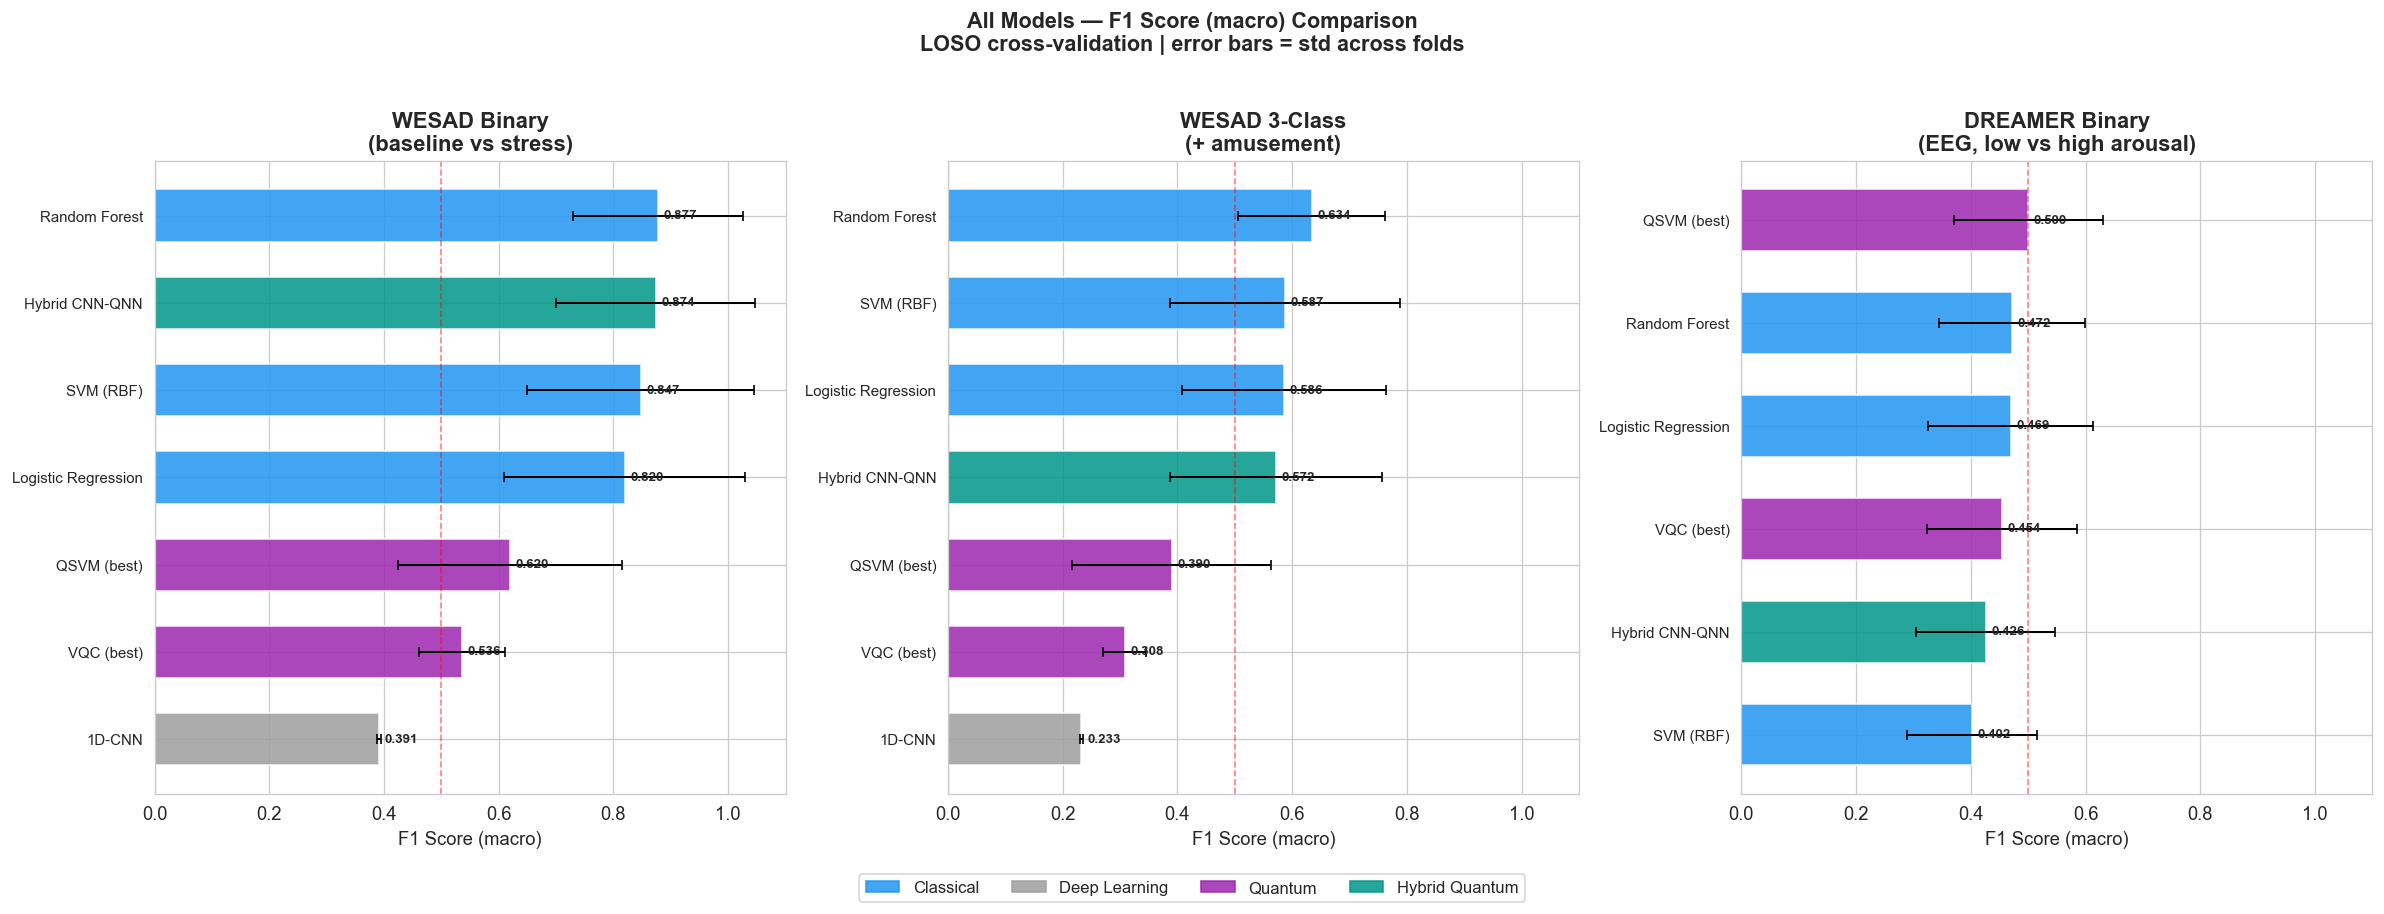

Saved: ..\results\plots\11_results_analysis\all_models_f1_comparison.png


In [14]:
# Color scheme by category
CATEGORY_COLORS = {
    'Classical'     : '#2196F3',
    'Deep Learning' : '#9E9E9E',
    'Quantum'       : '#9C27B0',
    'Hybrid Quantum': '#009688',
}

tasks_plot = [
    ('WESAD_binary',           'WESAD Binary\n(baseline vs stress)'),
    ('WESAD_3class',           'WESAD 3-Class\n(+ amusement)'),
    ('DREAMER_binary_EEG',     'DREAMER Binary\n(EEG, low vs high arousal)'),
]

# Map task names across notebooks
task_aliases = {
    'WESAD_binary'        : ['WESAD_binary', 'WESAD_binary_CNN',
                             'WESAD_binary_QSVM', 'WESAD_binary_VQC',
                             'WESAD_binary_Hybrid'],
    'WESAD_3class'        : ['WESAD_3class', 'WESAD_3class_CNN',
                             'WESAD_3class_QSVM', 'WESAD_3class_VQC',
                             'WESAD_3class_Hybrid'],
    'DREAMER_binary_EEG'  : ['DREAMER_binary_EEG', 'DREAMER_binary_EEG_QSVM',
                             'DREAMER_binary_EEG_VQC',
                             'DREAMER_binary_EEG_Hybrid'],
}

def get_task_rows(df_m, task_key):
    aliases = task_aliases.get(task_key, [task_key])
    return df_m[df_m['task'].isin(aliases)]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, (task_key, task_label) in zip(axes, tasks_plot):
    subset = get_task_rows(df_master, task_key)
    if len(subset) == 0:
        ax.set_title(task_label, fontweight='bold')
        ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                transform=ax.transAxes)
        continue

    subset = subset.sort_values('f1_mean', ascending=True)
    colors = [CATEGORY_COLORS.get(c, 'gray')
              for c in subset['category']]

    bars = ax.barh(range(len(subset)), subset['f1_mean'],
                   color=colors, alpha=0.85, height=0.6)
    ax.errorbar(subset['f1_mean'], range(len(subset)),
                xerr=subset['f1_std'], fmt='none',
                color='black', capsize=3, lw=1.2)

    for i, (_, row) in enumerate(subset.iterrows()):
        ax.text(row['f1_mean'] + 0.01, i,
                f'{row["f1_mean"]:.3f}',
                va='center', fontsize=8, fontweight='bold')

    # Shorten model names for display
    short_names = []
    for m in subset['model']:
        if 'QSVM (best:' in m:
            short_names.append('QSVM (best)')
        elif 'VQC (best:' in m:
            short_names.append('VQC (best)')
        else:
            short_names.append(m)

    ax.set_yticks(range(len(subset)))
    ax.set_yticklabels(short_names, fontsize=9)
    ax.set_xlabel('F1 Score (macro)')
    ax.set_title(task_label, fontweight='bold')
    ax.set_xlim(0, 1.1)
    ax.axvline(0.5, color='red', linestyle='--', lw=1, alpha=0.5)

# Legend
legend_patches = [mpatches.Patch(color=c, label=cat, alpha=0.85)
                  for cat, c in CATEGORY_COLORS.items()]
fig.legend(handles=legend_patches, loc='lower center',
           ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('All Models — F1 Score (macro) Comparison\n'
             'LOSO cross-validation | error bars = std across folds',
             fontweight='bold', y=1.02, fontsize=13)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'all_models_f1_comparison.png')
plt.savefig(p, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')


## 3. Training Time Comparison

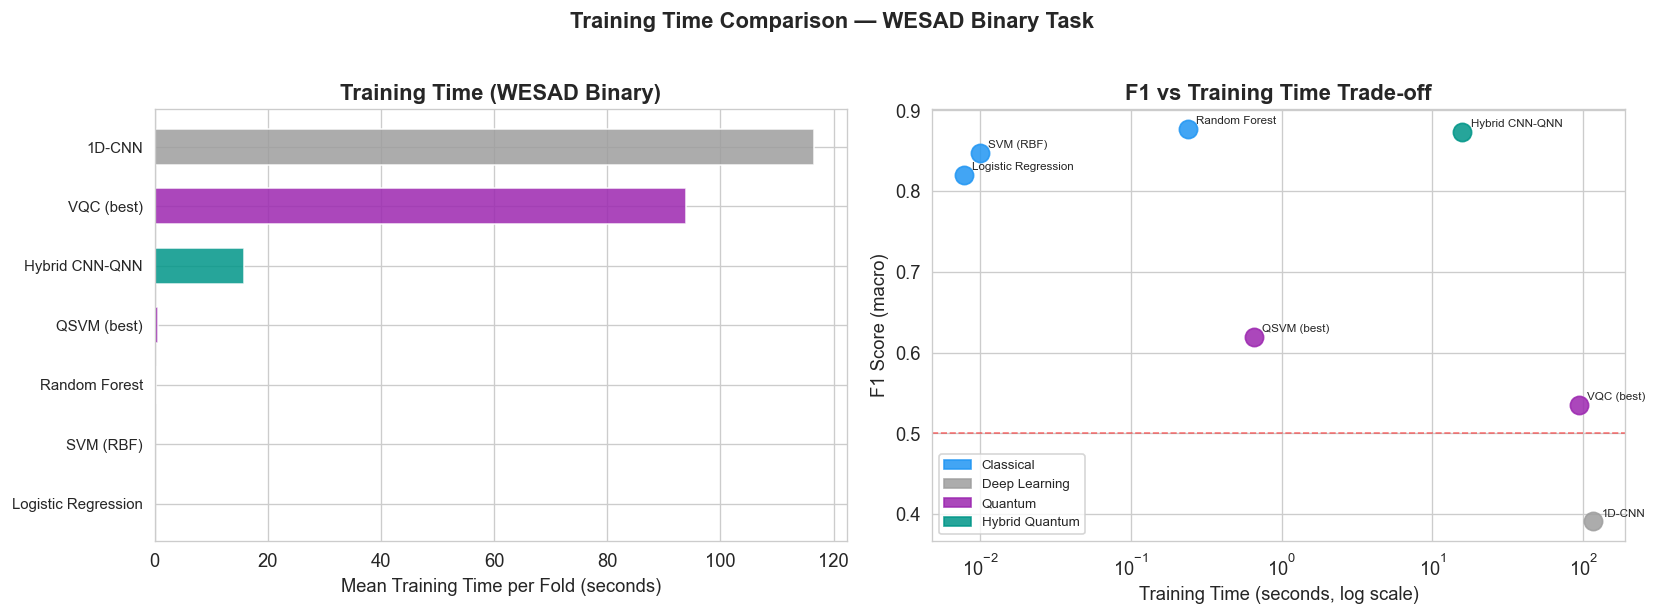

Saved: ..\results\plots\11_results_analysis\training_time_comparison.png


In [15]:
# Focus on WESAD binary for fair comparison
time_data = get_task_rows(df_master, 'WESAD_binary')[[
    'category','model','train_time_s','f1_mean']].copy()
time_data = time_data.sort_values('train_time_s')

# Shorten names
time_data['model_short'] = time_data['model'].apply(
    lambda x: 'QSVM (best)' if 'QSVM (best:' in x
              else ('VQC (best)' if 'VQC (best:' in x else x))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = [CATEGORY_COLORS.get(c,'gray') for c in time_data['category']]

# Training time
axes[0].barh(range(len(time_data)), time_data['train_time_s'],
             color=colors, alpha=0.85, height=0.6)
axes[0].set_yticks(range(len(time_data)))
axes[0].set_yticklabels(time_data['model_short'], fontsize=9)
axes[0].set_xlabel('Mean Training Time per Fold (seconds)')
axes[0].set_title('Training Time (WESAD Binary)', fontweight='bold')

# F1 vs training time scatter
for _, row in time_data.iterrows():
    color = CATEGORY_COLORS.get(row['category'], 'gray')
    axes[1].scatter(row['train_time_s'], row['f1_mean'],
                    color=color, s=120, zorder=3, alpha=0.85)
    axes[1].annotate(row['model_short'],
                     (row['train_time_s'], row['f1_mean']),
                     textcoords='offset points',
                     xytext=(5, 3), fontsize=7)

axes[1].set_xlabel('Training Time (seconds, log scale)')
axes[1].set_ylabel('F1 Score (macro)')
axes[1].set_xscale('log')
axes[1].set_title('F1 vs Training Time Trade-off', fontweight='bold')
axes[1].axhline(0.5, color='red', linestyle='--', lw=1, alpha=0.5)

legend_patches = [mpatches.Patch(color=c, label=cat, alpha=0.85)
                  for cat, c in CATEGORY_COLORS.items()]
axes[1].legend(handles=legend_patches, fontsize=8)

plt.suptitle('Training Time Comparison — WESAD Binary Task',
             fontweight='bold', y=1.02)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'training_time_comparison.png')
plt.savefig(p, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')


## 4. Stress/Amusement Overlap Analysis
How well does each model distinguish stress from amusement in the 3-class task?

=== Stress/Amusement Confusion Rates — All Models ===
(Lower = better at separating stress from amusement)

                                                     model  stress->amusement_rate  amusement->stress_rate
                                       Logistic Regression                  0.1150                  0.0482
                                                 SVM (RBF)                  0.1246                  0.0602
                                             Random Forest                  0.0511                  0.1145
 QSVM (ZZFeatureMap | n_qubits=3 | reps=2 | full | robust)                  0.2684                  0.2229
VQC-COBYLA (EfficientSU2 | n_qubits=3 | reps=1 | circular)                  0.0000                  0.5120


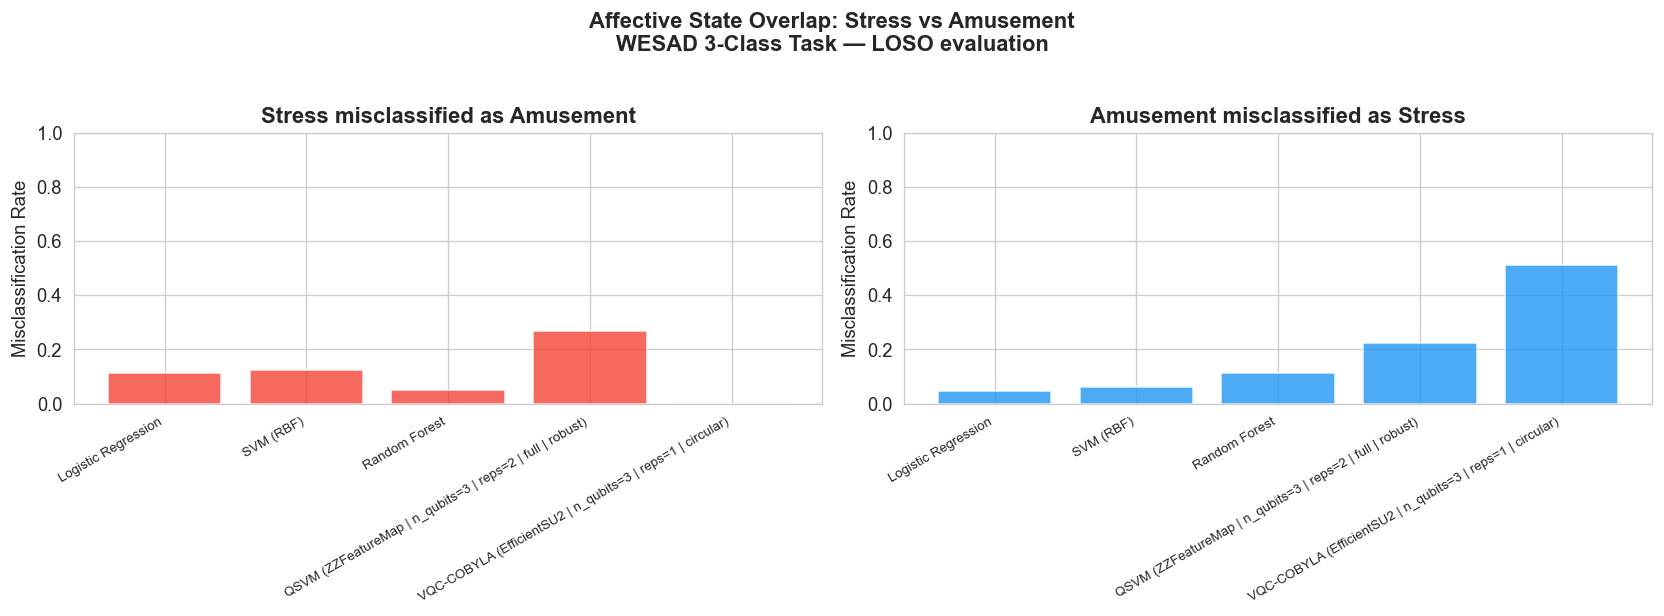


Saved: ..\results\plots\11_results_analysis\stress_amusement_overlap_all_models.png


In [16]:
if df_overlap is not None:
    print('=== Stress/Amusement Confusion Rates — All Models ===')
    print('(Lower = better at separating stress from amusement)')
    print()
    print(df_overlap.round(4).to_string(index=False))

    # Bar chart
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x = range(len(df_overlap))

    axes[0].bar(x, df_overlap['stress->amusement_rate'],
                color='#F44336', alpha=0.8)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(df_overlap['model'],
                             rotation=30, ha='right', fontsize=8)
    axes[0].set_ylabel('Misclassification Rate')
    axes[0].set_title('Stress misclassified as Amusement',
                      fontweight='bold')
    axes[0].set_ylim(0, 1)

    axes[1].bar(x, df_overlap['amusement->stress_rate'],
                color='#2196F3', alpha=0.8)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(df_overlap['model'],
                             rotation=30, ha='right', fontsize=8)
    axes[1].set_ylabel('Misclassification Rate')
    axes[1].set_title('Amusement misclassified as Stress',
                      fontweight='bold')
    axes[1].set_ylim(0, 1)

    plt.suptitle('Affective State Overlap: Stress vs Amusement\n'
                 'WESAD 3-Class Task — LOSO evaluation',
                 fontweight='bold', y=1.02)
    plt.tight_layout()
    p = os.path.join(PLOTS_DIR, 'stress_amusement_overlap_all_models.png')
    plt.savefig(p, bbox_inches='tight')
    plt.show()
    print(f'\nSaved: {p}')
else:
    print('overlap_all_models.csv not found — run notebooks 05, 07, 08, 09 first.')


## 5. Quantum vs Classical Gap Analysis

In [17]:
print('=== QUANTUM vs CLASSICAL GAP ===')
print()

gap_rows = []
for task_key, task_label in [
        ('WESAD_binary',      'WESAD Binary'),
        ('WESAD_3class',      'WESAD 3-Class'),
        ('DREAMER_binary_EEG','DREAMER Binary EEG')]:

    subset = get_task_rows(df_master, task_key)
    if len(subset) == 0:
        continue

    classical_f1 = subset[subset['category']=='Classical']['f1_mean'].max()
    quantum_f1   = subset[subset['category']=='Quantum']['f1_mean'].max()
    hybrid_f1    = subset[subset['category']=='Hybrid Quantum']['f1_mean'].max()
    cnn_f1       = subset[subset['category']=='Deep Learning']['f1_mean'].max()

    best_classical = subset[subset['category']=='Classical']\
        .loc[subset[subset['category']=='Classical']['f1_mean'].idxmax(),'model']

    gap_q  = classical_f1 - quantum_f1   if not np.isnan(quantum_f1)  else np.nan
    gap_h  = classical_f1 - hybrid_f1   if not np.isnan(hybrid_f1)   else np.nan

    gap_rows.append({
        'task'          : task_label,
        'best_classical': round(classical_f1, 4),
        'best_classical_model': best_classical,
        'best_quantum'  : round(quantum_f1,  4) if not np.isnan(quantum_f1)  else 'N/A',
        'best_hybrid'   : round(hybrid_f1,   4) if not np.isnan(hybrid_f1)   else 'N/A',
        'cnn_f1'        : round(cnn_f1,      4) if not np.isnan(cnn_f1)      else 'N/A',
        'q_gap'         : round(gap_q, 4)        if not np.isnan(gap_q)       else 'N/A',
        'hybrid_gap'    : round(gap_h, 4)        if not np.isnan(gap_h)       else 'N/A',
    })

    print(f'{task_label}:')
    print(f'  Best Classical  : {classical_f1:.4f} ({best_classical})')
    if not np.isnan(quantum_f1):
        print(f'  Best Quantum    : {quantum_f1:.4f}  gap={gap_q:.4f}')
    if not np.isnan(hybrid_f1):
        print(f'  Best Hybrid     : {hybrid_f1:.4f}  gap={gap_h:.4f}')
    if not np.isnan(cnn_f1):
        print(f'  1D-CNN          : {cnn_f1:.4f}')
    print()

df_gap = pd.DataFrame(gap_rows)
p = os.path.join(OUTPUT_DATA_DIR, 'quantum_classical_gap.csv')
df_gap.to_csv(p, index=False)
print(f'Saved: {p}')


=== QUANTUM vs CLASSICAL GAP ===

WESAD Binary:
  Best Classical  : 0.8769 (Random Forest)
  Best Quantum    : 0.6198  gap=0.2571
  Best Hybrid     : 0.8735  gap=0.0034
  1D-CNN          : 0.3910

WESAD 3-Class:
  Best Classical  : 0.6344 (Random Forest)
  Best Quantum    : 0.3898  gap=0.2446
  Best Hybrid     : 0.5716  gap=0.0628
  1D-CNN          : 0.2328

DREAMER Binary EEG:
  Best Classical  : 0.4722 (Random Forest)
  Best Quantum    : 0.4999  gap=-0.0277
  Best Hybrid     : 0.4258  gap=0.0464

Saved: ..\results\output_data\quantum_classical_gap.csv


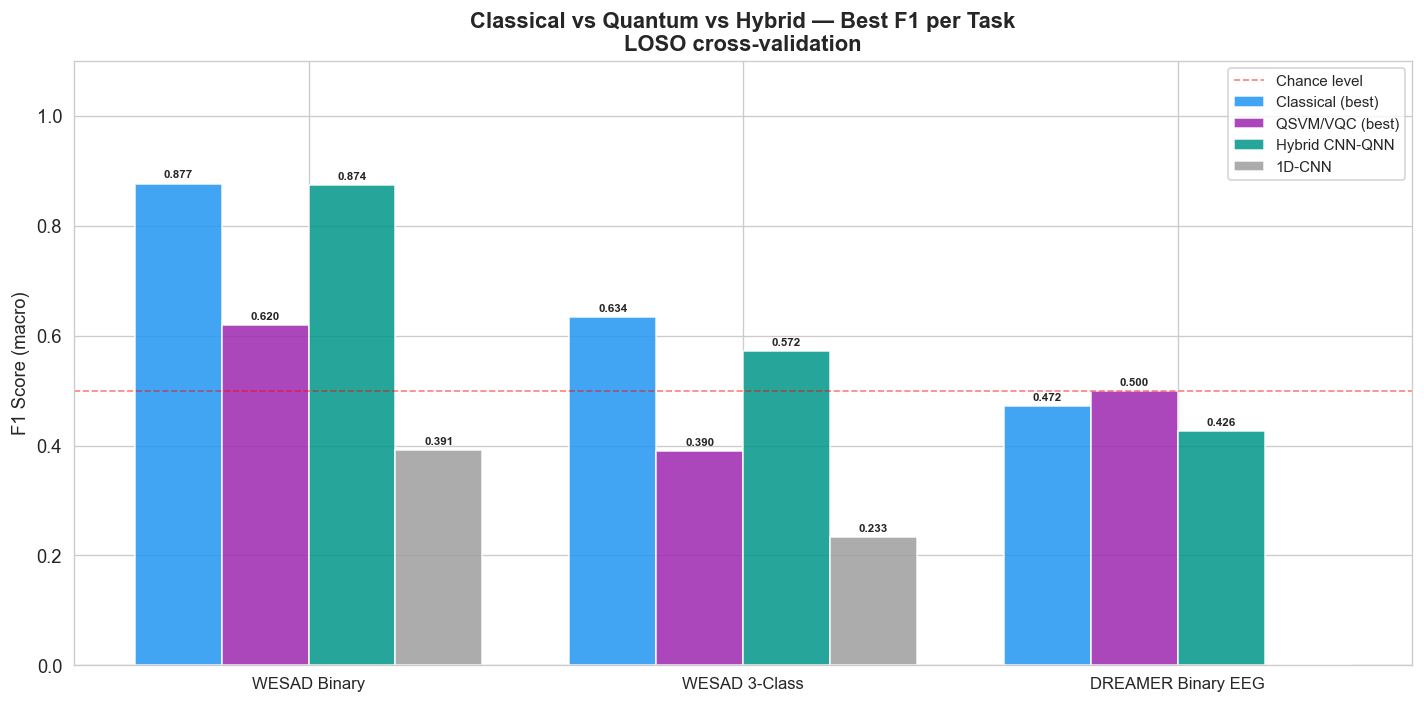

Saved: ..\results\plots\11_results_analysis\classical_quantum_hybrid_comparison.png


In [18]:
# Gap visualization
tasks_gap = [r['task'] for r in gap_rows]
x = np.arange(len(tasks_gap))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))

# Plot each category
for i, (col, label, color) in enumerate([
        ('best_classical', 'Classical (best)', '#2196F3'),
        ('best_quantum',   'QSVM/VQC (best)',  '#9C27B0'),
        ('best_hybrid',    'Hybrid CNN-QNN',   '#009688'),
        ('cnn_f1',         '1D-CNN',           '#9E9E9E')]):

    vals = []
    for r in gap_rows:
        v = r.get(col, 'N/A')
        vals.append(float(v) if v != 'N/A' else 0)

    bars = ax.bar(x + i*width, vals, width, label=label,
                  color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center',
                    fontsize=7, fontweight='bold')

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(tasks_gap, fontsize=10)
ax.set_ylabel('F1 Score (macro)')
ax.set_ylim(0, 1.1)
ax.axhline(0.5, color='red', linestyle='--', lw=1, alpha=0.5,
           label='Chance level')
ax.legend(fontsize=9)
ax.set_title('Classical vs Quantum vs Hybrid — Best F1 per Task\n'
             'LOSO cross-validation',
             fontweight='bold')
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'classical_quantum_hybrid_comparison.png')
plt.savefig(p, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')


## 6. Cross-Dataset Summary Plot

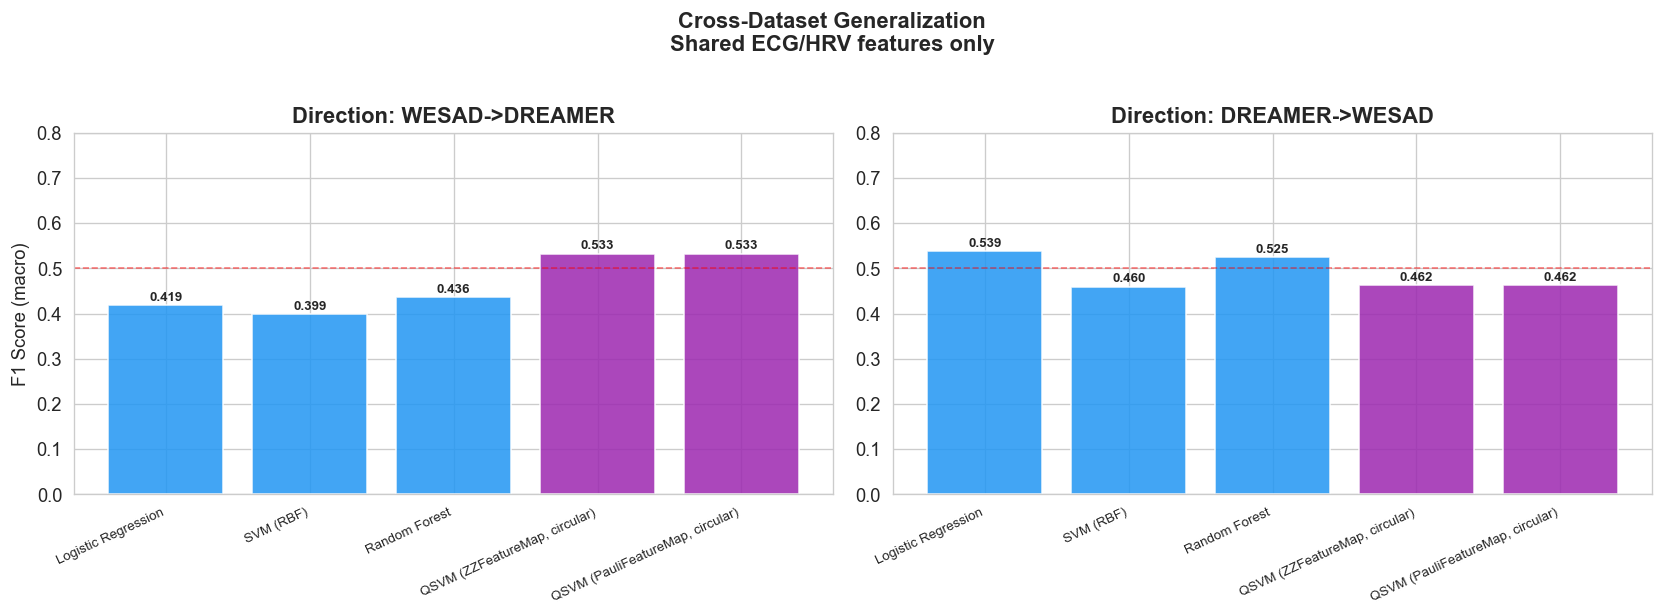

Saved: ..\results\plots\11_results_analysis\cross_dataset_summary.png


In [19]:
if df_cross is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, direction in zip(axes,
            ['WESAD->DREAMER', 'DREAMER->WESAD']):
        subset = df_cross[df_cross['direction']==direction]
        models = subset['model'].tolist()
        f1s    = subset['f1'].tolist()

        bar_colors = []
        for m in models:
            if 'QSVM' in m:
                bar_colors.append('#9C27B0')
            elif m in ['Logistic Regression','SVM (RBF)','Random Forest']:
                bar_colors.append('#2196F3')
            else:
                bar_colors.append('gray')

        bars = ax.bar(range(len(models)), f1s,
                      color=bar_colors, alpha=0.85)
        for bar, val in zip(bars, f1s):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center',
                    fontsize=8, fontweight='bold')
        ax.set_xticks(range(len(models)))
        ax.set_xticklabels(models, rotation=25,
                           ha='right', fontsize=8)
        ax.set_ylabel('F1 Score (macro)' if ax==axes[0] else '')
        ax.set_ylim(0, 0.8)
        ax.set_title(f'Direction: {direction}', fontweight='bold')
        ax.axhline(0.5, color='red', linestyle='--',
                   lw=1, alpha=0.5, label='chance')

    plt.suptitle('Cross-Dataset Generalization\n'
                 'Shared ECG/HRV features only',
                 fontweight='bold', y=1.02)
    plt.tight_layout()
    p = os.path.join(PLOTS_DIR, 'cross_dataset_summary.png')
    plt.savefig(p, bbox_inches='tight')
    plt.show()
    print(f'Saved: {p}')


## 7. Per-Subject Variability (WESAD Binary)

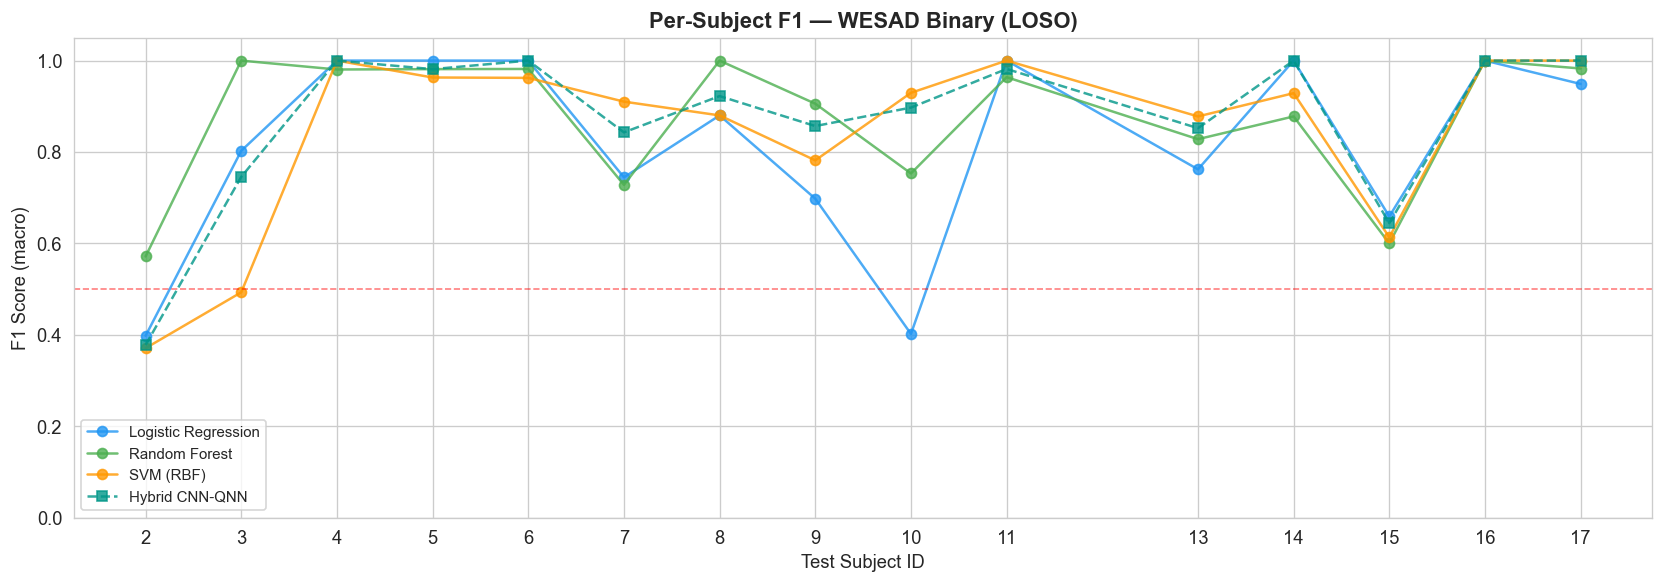

Saved: ..\results\plots\11_results_analysis\per_subject_f1_wesad_binary.png

=== Hard Subjects (mean F1 < 0.6 across classical models) ===
test_subject
2    0.447


In [20]:
# Show per-subject F1 for all models on WESAD binary
# to visualise which subjects are hard
if df_classical is not None:
    wb_classical = df_classical[
        df_classical['task']=='WESAD_binary'].copy()

    fig, ax = plt.subplots(figsize=(14, 5))
    model_colors_map = {
        'Logistic Regression': '#2196F3',
        'SVM (RBF)'          : '#FF9800',
        'Random Forest'      : '#4CAF50',
    }

    for model, g in wb_classical.groupby('model'):
        g_sorted = g.sort_values('test_subject')
        ax.plot(g_sorted['test_subject'], g_sorted['f1'],
                marker='o', lw=1.5, alpha=0.8,
                color=model_colors_map.get(model,'gray'),
                label=model)

    # Add hybrid if available
    if df_hybrid is not None:
        wb_hybrid = df_hybrid[
            df_hybrid['task']=='WESAD_binary_Hybrid'].copy()
        if len(wb_hybrid) > 0:
            wb_sorted = wb_hybrid.sort_values('test_subject')
            ax.plot(wb_sorted['test_subject'], wb_sorted['f1'],
                    marker='s', lw=1.5, alpha=0.8,
                    color='#009688', linestyle='--',
                    label='Hybrid CNN-QNN')

    ax.set_xlabel('Test Subject ID')
    ax.set_ylabel('F1 Score (macro)')
    ax.set_title('Per-Subject F1 — WESAD Binary (LOSO)',
                 fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color='red', linestyle='--', lw=1, alpha=0.5)
    ax.set_xticks(sorted(wb_classical['test_subject'].unique()))

    plt.tight_layout()
    p = os.path.join(PLOTS_DIR, 'per_subject_f1_wesad_binary.png')
    plt.savefig(p, bbox_inches='tight')
    plt.show()
    print(f'Saved: {p}')

    # Identify consistently hard subjects
    print('\n=== Hard Subjects (mean F1 < 0.6 across classical models) ===')
    subj_mean = wb_classical.groupby('test_subject')['f1'].mean()
    hard = subj_mean[subj_mean < 0.6].sort_values()
    print(hard.round(3).to_string())


## 8. Final Paper-Ready Summary Table

In [21]:
print('=' * 70)
print('FINAL RESULTS SUMMARY — FOR PAPER')
print('=' * 70)
print()

task_labels = {
    'WESAD_binary'      : 'WESAD Binary',
    'WESAD_3class'      : 'WESAD 3-Class',
    'DREAMER_binary_EEG': 'DREAMER Binary (EEG)',
}

for task_key, task_label in task_labels.items():
    subset = get_task_rows(df_master, task_key)
    if len(subset) == 0:
        continue
    print(f'--- {task_label} ---')
    print(f'{"Model":<35} {"Category":<16} '
          f'{"F1 mean":>8} {"F1 std":>8} '
          f'{"Acc":>8} {"Time(s)":>8}')
    print('-' * 85)

    subset_sorted = subset.sort_values('f1_mean', ascending=False)
    for _, row in subset_sorted.iterrows():
        model = row['model']
        if 'QSVM (best:' in model: model = 'QSVM (best config)'
        if 'VQC (best:'  in model: model = 'VQC (best config)'
        print(f'{model:<35} {row["category"]:<16} '
              f'{row["f1_mean"]:>8.4f} {row["f1_std"]:>8.4f} '
              f'{row["accuracy_mean"]:>8.4f} '
              f'{row["train_time_s"]:>8.2f}')
    print()


FINAL RESULTS SUMMARY — FOR PAPER

--- WESAD Binary ---
Model                               Category          F1 mean   F1 std      Acc  Time(s)
-------------------------------------------------------------------------------------
Random Forest                       Classical          0.8769   0.1482   0.8943     0.24
Hybrid CNN-QNN                      Hybrid Quantum     0.8735   0.1737   0.9025    15.79
SVM (RBF)                           Classical          0.8474   0.1983   0.8862     0.01
Logistic Regression                 Classical          0.8197   0.2101   0.8534     0.01
QSVM (best config)                  Quantum            0.6198   0.1954   0.6413     0.65
VQC (best config)                   Quantum            0.5357   0.0752   0.5516    93.99
1D-CNN                              Deep Learning      0.3910   0.0037   0.6420   116.50

--- WESAD 3-Class ---
Model                               Category          F1 mean   F1 std      Acc  Time(s)
----------------------------------

## 9. Summary Log

In [22]:
summary = {
    'notebook'  : '11_results_analysis',
    'timestamp' : datetime.now().isoformat(),
    'files_generated': [
        'master_results_table.csv',
        'quantum_classical_gap.csv',
        'all_models_f1_comparison.png',
        'training_time_comparison.png',
        'stress_amusement_overlap_all_models.png',
        'classical_quantum_hybrid_comparison.png',
        'cross_dataset_summary.png',
        'per_subject_f1_wesad_binary.png',
    ],
    'key_findings': {
        'best_overall'            : 'Random Forest / Hybrid CNN-QNN on WESAD binary',
        'quantum_gap_wesad_binary': 'QSVM and VQC underperform classical by ~20-30% F1',
        'hybrid_performance'      : 'Hybrid CNN-QNN nearly matches classical RF on WESAD binary',
        'dreamer_difficulty'      : 'All models near chance on DREAMER — cross-subject EEG hard',
        'cross_dataset'           : 'Near-chance cross-dataset generalization with shared ECG features',
        'kernel_concentration'    : 'QSVM kernels collapse toward identity matrix at 6+ qubits',
        'vqc_convergence'         : 'VQC near-chance — barren plateau + insufficient optimization',
        'overlap_problem'         : 'Stress/amusement confusion documented across all models',
    }
}

p = os.path.join(LOGS_DIR, '11_results_analysis_summary.json')
with open(p,'w') as f: json.dump(summary, f, indent=2)

print('=' * 60)
print('RESULTS ANALYSIS COMPLETE')
print('=' * 60)
print(json.dumps(summary, indent=2))
print(f'\nLog saved: {p}')


RESULTS ANALYSIS COMPLETE
{
  "notebook": "11_results_analysis",
  "timestamp": "2026-05-11T18:36:10.562313",
  "files_generated": [
    "master_results_table.csv",
    "quantum_classical_gap.csv",
    "all_models_f1_comparison.png",
    "training_time_comparison.png",
    "stress_amusement_overlap_all_models.png",
    "classical_quantum_hybrid_comparison.png",
    "cross_dataset_summary.png",
    "per_subject_f1_wesad_binary.png"
  ],
  "key_findings": {
    "best_overall": "Random Forest / Hybrid CNN-QNN on WESAD binary",
    "quantum_gap_wesad_binary": "QSVM and VQC underperform classical by ~20-30% F1",
    "hybrid_performance": "Hybrid CNN-QNN nearly matches classical RF on WESAD binary",
    "dreamer_difficulty": "All models near chance on DREAMER \u2014 cross-subject EEG hard",
    "cross_dataset": "Near-chance cross-dataset generalization with shared ECG features",
    "kernel_concentration": "QSVM kernels collapse toward identity matrix at 6+ qubits",
    "vqc_convergence": "V